In [2]:
# import Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import needed packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Data for Glioma Grading

In [4]:
# import data
initialdata = pd.read_csv('/content/drive/MyDrive/MSBD 566 Predictive Modeling /Mid-Term Project/glioma+grading+clinical+and+mutation+features+dataset/TCGA_InfoWithGrade.csv')
initialdata.head()

,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Check for missing values and dataset shape

In [5]:
initialdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 839 entries, 0 to 838
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Grade             839 non-null    int64  
 1   Gender            839 non-null    int64  
 2   Age_at_diagnosis  839 non-null    float64
 3   Race              839 non-null    int64  
 4   IDH1              839 non-null    int64  
 5   TP53              839 non-null    int64  
 6   ATRX              839 non-null    int64  
 7   PTEN              839 non-null    int64  
 8   EGFR              839 non-null    int64  
 9   CIC               839 non-null    int64  
 10  MUC16             839 non-null    int64  
 11  PIK3CA            839 non-null    int64  
 12  NF1               839 non-null    int64  
 13  PIK3R1            839 non-null    int64  
 14  FUBP1             839 non-null    int64  
 15  RB1               839 non-null    int64  
 16  NOTCH1            839 non-null    int64  
 1

# Check the Distribution of the Demographic Variables

,Age_at_diagnosis
count,839.000000
mean,50.935411
std,15.702339
min,14.420000
25%,38.055000
50%,51.550000
75%,62.800000
max,89.290000


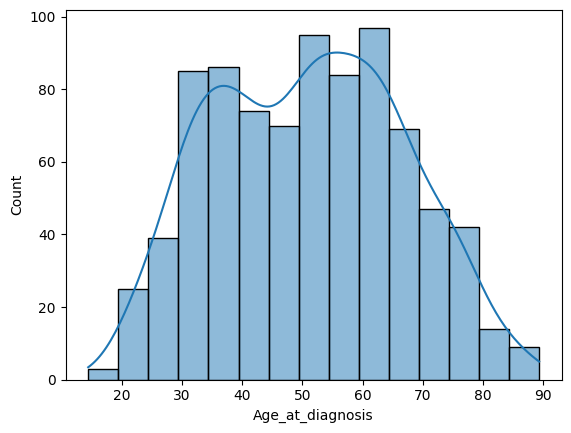

In [6]:
display(initialdata['Age_at_diagnosis'].describe())

# distribution graph of age
sns.histplot(initialdata['Age_at_diagnosis'], kde = True)
plt.show()

,count
Grade,
0,487
1,352


,count
Grade,
0,58.045292
1,41.954708


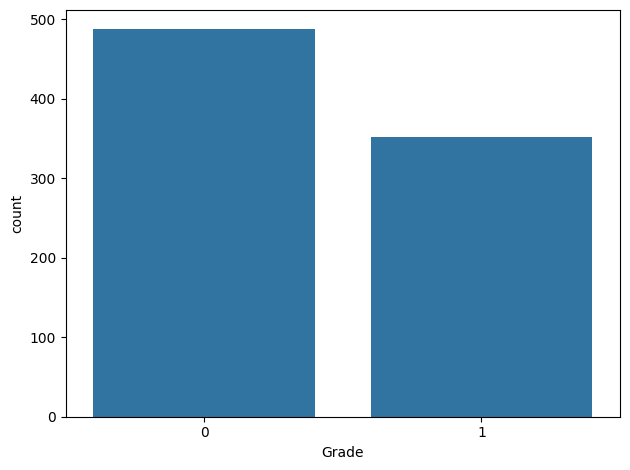

In [7]:
grade_data = initialdata['Grade'].value_counts()
display(grade_data)
display(grade_data * 100 / len(initialdata))

sns.countplot(data = initialdata, x = 'Grade')
plt.tight_layout()
plt.show()

Gender
0    488
1    351
Name: count, dtype: int64


,count
Gender,
0,58.164482
1,41.835518


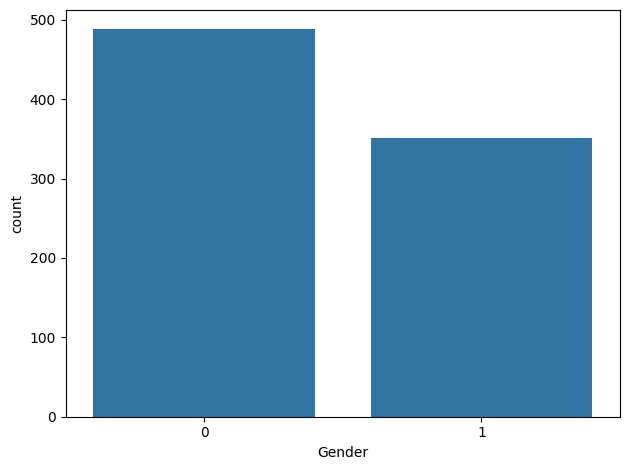

In [8]:
gender_data = initialdata['Gender'].value_counts()
print(gender_data)

display(gender_data * 100 / len(initialdata))

sns.countplot(data = initialdata, x = 'Gender')
plt.tight_layout()
plt.show()

Race
0    765
1     59
2     14
3      1
Name: count, dtype: int64


,count
Race,
0,91.179976
1,7.032181
2,1.668653
3,0.119190


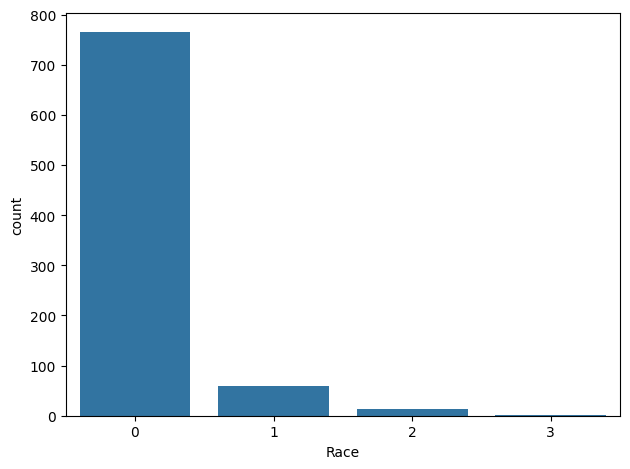

In [9]:
racial_data = initialdata['Race'].value_counts()
print(racial_data)

display(racial_data * 100 / len(initialdata))

sns.countplot(data = initialdata, x = 'Race')
plt.tight_layout()
plt.show()

The race columns covers 4 groups:
*   0 = White
*   1 = Black or African American
*   2 = Asian
*   3 = American Indian or Alaska Native

There is a distinct imbalance in this dataset because 91% of the patients that are represented are 'White'. To promote fairness and mitigate bias while training the model, I will exclude the racial column for the initial testing. Race will be re-integrated to compare any differences in the model's prediction using race-aware resampling and fairness evaluations.




In [10]:
data = initialdata.drop(columns=['Race'])
data.head()

,Grade,Gender,Age_at_diagnosis,IDH1,TP53,ATRX,PTEN,EGFR,CIC,MUC16,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Identify feature types

In [12]:
numeric_features = data['Age_at_diagnosis']
categorical_features = data['Gender']
mutation_features = data.drop(columns=['Age_at_diagnosis', 'Gender', 'Grade'])

#Check the Distribution of Mutation Variables

In [16]:
summary = []
n = len(data)

for gene in mutation_features.columns: # Iterate through column names (gene names)
    counts = data[gene].value_counts().sort_index()
    count_0 = counts.get(0, 0)
    count_1 = counts.get(1, 0)
    pct_0 = (count_0 / n) * 100
    pct_1 = (count_1 / n) * 100

    summary.append({
        "Gene": gene,
        "# Non-Mutated": count_0,
        "# Mutated": count_1,
        "% Non-Mut": round(pct_0, 2),
        "% Mut": round(pct_1, 2)
    })

# === 4. Build & display the summary table ===
summary_df = pd.DataFrame(summary).sort_values("% Non-Mut", ascending=False).reset_index(drop=True)
display(summary_df)

,Gene,# Non-Mutated,# Mutated,% Non-Mut,% Mut
0,PDGFRA,817,22,97.38,2.62
1,IDH2,816,23,97.26,2.74
2,FAT4,816,23,97.26,2.74
3,SMARCA4,812,27,96.78,3.22
4,GRIN2A,812,27,96.78,3.22
5,CSMD3,812,27,96.78,3.22
6,BCOR,810,29,96.54,3.46
7,NOTCH1,801,38,95.47,4.53
8,RB1,799,40,95.23,4.77
9,FUBP1,794,45,94.64,5.36


# Correlation Heat Maps

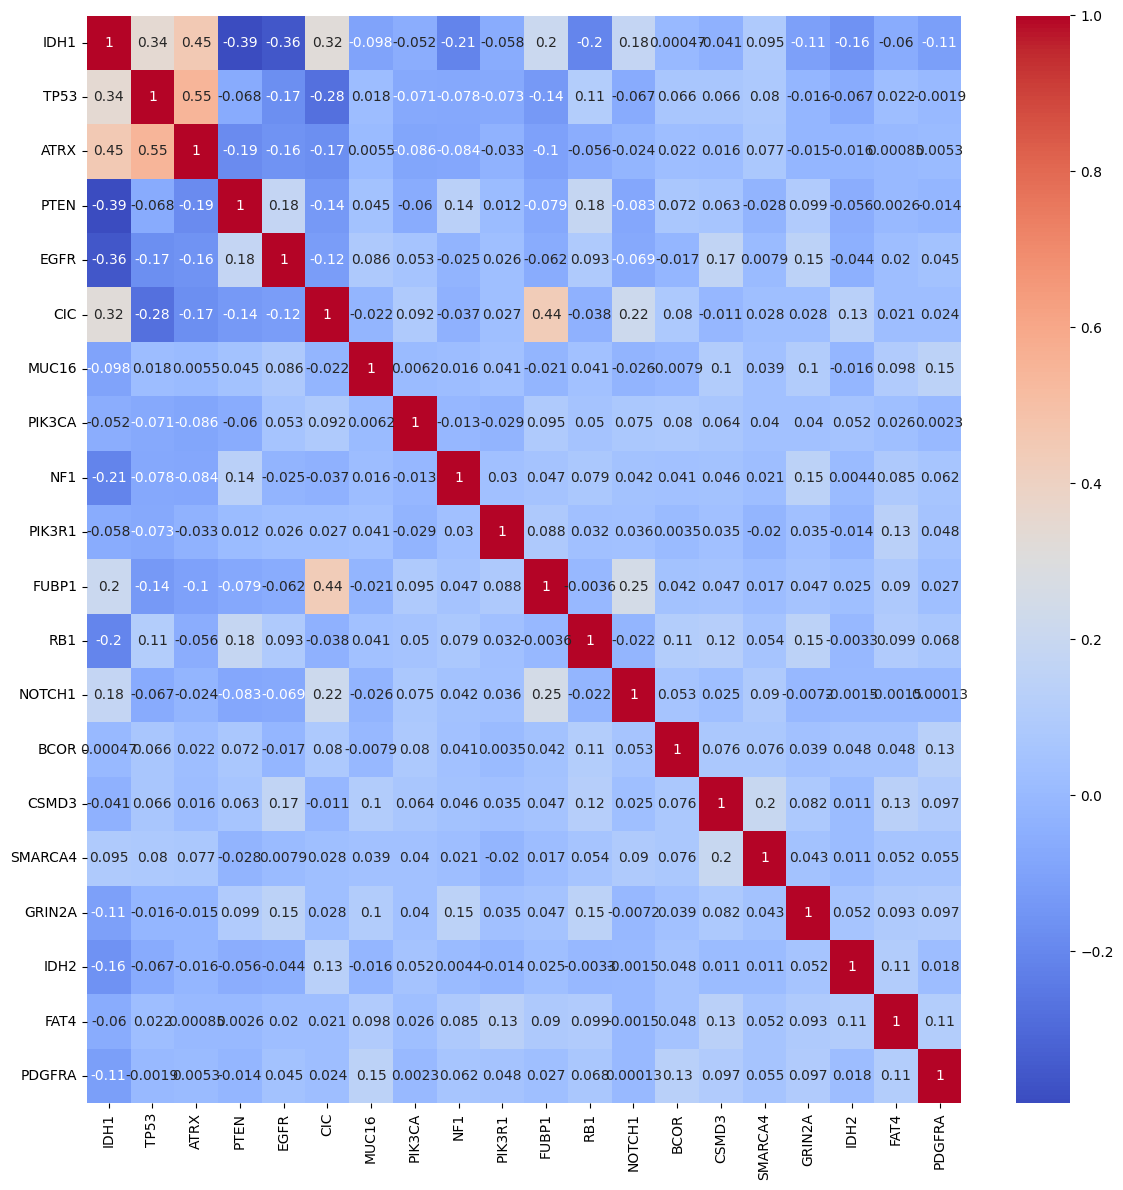

In [25]:
#Gene Mutations Only
corr_map = mutation_features.corr()
plt.figure(figsize = (12, 12))
sns.heatmap(corr_map, annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()


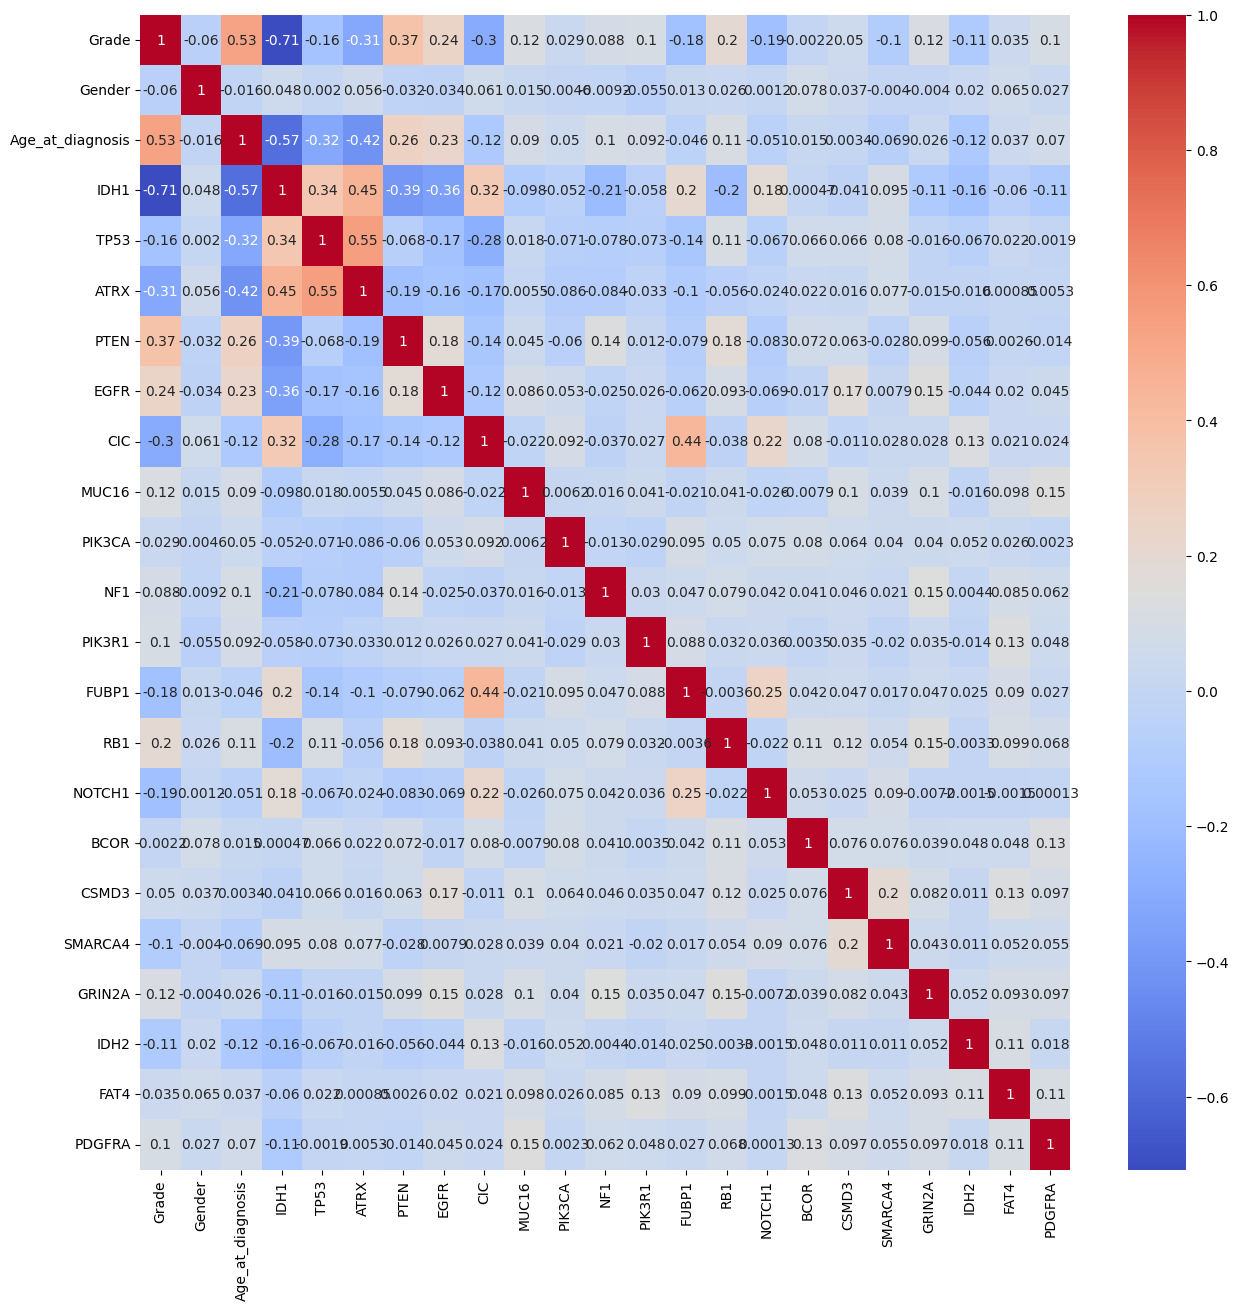

In [23]:
#Clinical + Mutations
corr_map = data.corr()
plt.figure(figsize = (15, 15))
sns.heatmap(corr_map, annot=True, cmap='coolwarm')
plt.show()

# Model Preprocessing



In [ ]:
pip install pandas scikit-learn xgboost catboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix,
    roc_curve, auc
)

In [ ]:
# Declare the variables
X = data.drop(columns=['Grade'])
y = data['Grade']

#Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify = y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train grade balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test grade balance:\n", y_test.value_counts(normalize=True).round(3))

# Scale Age_at_diagnosis
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled["Age_at_diagnosis"] = scaler.fit_transform(X_train[["Age_at_diagnosis"]])
X_test_scaled["Age_at_diagnosis"] = scaler.transform(X_test[["Age_at_diagnosis"]])

Train size: (671, 22)  Test size: (168, 22)
Train grade balance:
 Grade
0    0.58
1    0.42
Name: proportion, dtype: float64
Test grade balance:
 Grade
0    0.583
1    0.417
Name: proportion, dtype: float64


#Logistic Regression

Log Reg Train:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       389
           1       0.81      0.89      0.85       282

    accuracy                           0.87       671
   macro avg       0.86      0.87      0.86       671
weighted avg       0.87      0.87      0.87       671

Log Reg Test:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        98
           1       0.82      0.90      0.86        70

    accuracy                           0.88       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.88      0.88      0.88       168



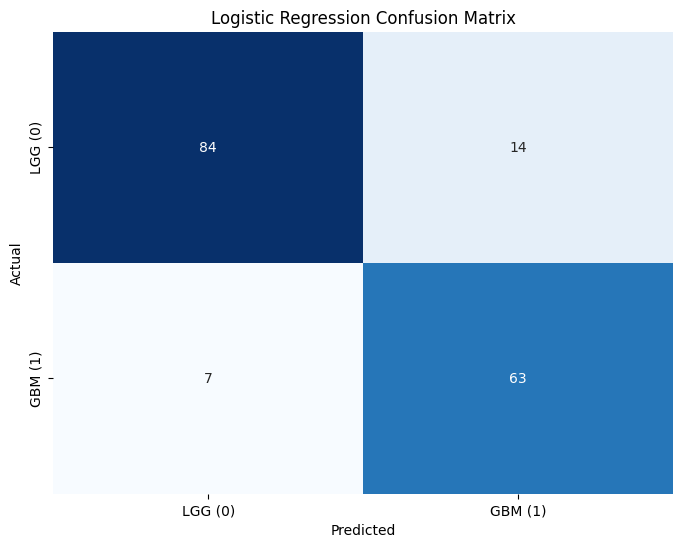

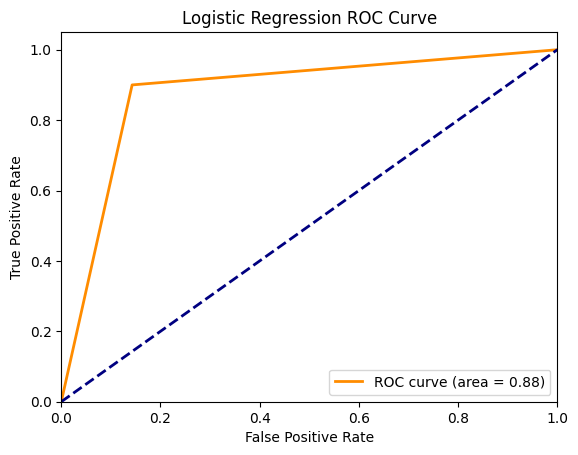

In [ ]:
# Establish the model
logreg = LogisticRegression(
    random_state = 42,
    C = 0.1,
    solver = 'lbfgs'
)

# Train the model
logreg.fit(X_train_scaled, y_train)

# Predict glioma class labels
y_pred_logregtrain = logreg.predict(X_train_scaled)
y_pred_logregtest = logreg.predict(X_test_scaled)

# Evaluate the model

print("Log Reg Train:")
print(classification_report(y_train, y_pred_logregtrain))

print("Log Reg Test:")
print(classification_report(y_test, y_pred_logregtest))

logreg_cm = confusion_matrix(y_test, y_pred_logregtest)
plt.figure(figsize=(8, 6))
sns.heatmap(
    logreg_cm,
    annot=True,
    fmt='d', cmap='Blues', cbar=False,
    xticklabels = ['LGG (0)', 'GBM (1)'],
    yticklabels = ['LGG (0)', 'GBM (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_logregtest)
lr_roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % lr_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc="lower right")
plt.show()

#Random Forest

Random Forest Train:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       389
           1       0.83      0.93      0.88       282

    accuracy                           0.89       671
   macro avg       0.89      0.90      0.89       671
weighted avg       0.90      0.89      0.89       671

Random Forest Test:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88        98
           1       0.79      0.91      0.85        70

    accuracy                           0.86       168
   macro avg       0.86      0.87      0.86       168
weighted avg       0.87      0.86      0.86       168



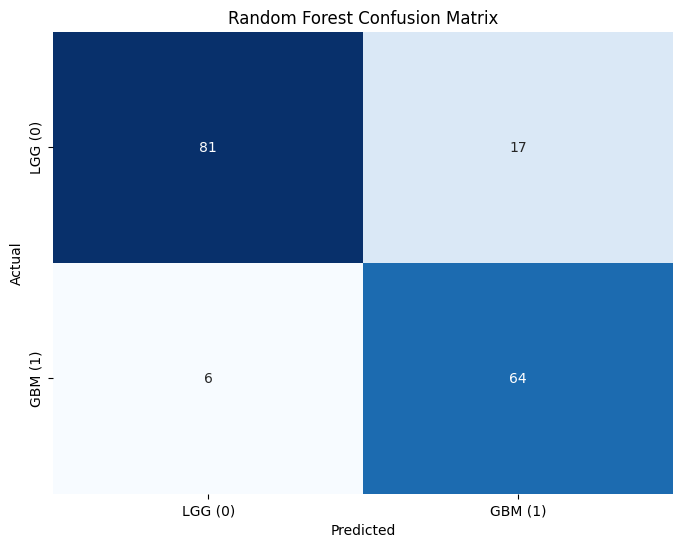

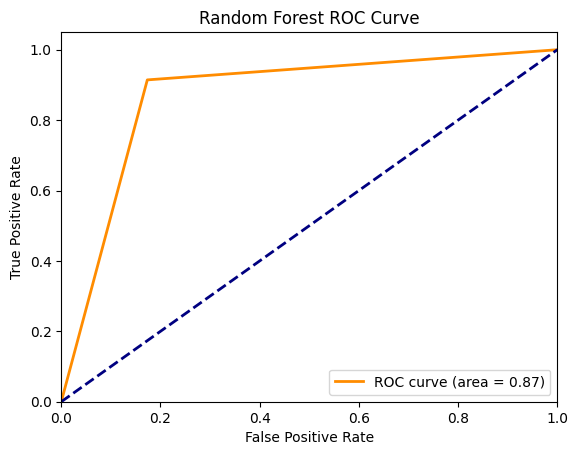

In [ ]:
# Establish the model
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 20,
    min_samples_split = 5,
    min_samples_leaf = 2
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Predict glioma class labels
y_pred_rftrain = rf.predict(X_train_scaled)
y_pred_rftest = rf.predict(X_test_scaled)

# Evaluate the model

print("Random Forest Train:")
print(classification_report(y_train, y_pred_rftrain))

print("Random Forest Test:")
print(classification_report(y_test, y_pred_rftest))

rf_cm = confusion_matrix(y_test, y_pred_rftest)
plt.figure(figsize=(8, 6))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d', cmap='Blues', cbar=False,
    xticklabels = ['LGG (0)', 'GBM (1)'],
    yticklabels = ['LGG (0)', 'GBM (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_rftest)
rf_roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % rf_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Features ranked by importance
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by = "Importance", ascending = False)

print("\nRanking of Important Features:")
print(importances)



Ranking of Important Features:
             Feature  Importance
2               IDH1    0.400989
1   Age_at_diagnosis    0.232507
5               PTEN    0.069726
4               ATRX    0.064256
7                CIC    0.044449
19              IDH2    0.034749
6               EGFR    0.022968
3               TP53    0.022789
12             FUBP1    0.014076
13               RB1    0.013907
10               NF1    0.013543
8              MUC16    0.012019
14            NOTCH1    0.011517
0             Gender    0.010521
11            PIK3R1    0.009270
9             PIK3CA    0.006625
15              BCOR    0.004043
21            PDGFRA    0.003455
18            GRIN2A    0.002486
20              FAT4    0.002318
17           SMARCA4    0.002000
16             CSMD3    0.001786


#XGBoost

XGBoost Train:
              precision    recall  f1-score   support

           0       0.93      0.88      0.91       389
           1       0.85      0.91      0.88       282

    accuracy                           0.90       671
   macro avg       0.89      0.90      0.90       671
weighted avg       0.90      0.90      0.90       671

XGBoost Test:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        98
           1       0.81      0.86      0.83        70

    accuracy                           0.86       168
   macro avg       0.85      0.86      0.85       168
weighted avg       0.86      0.86      0.86       168



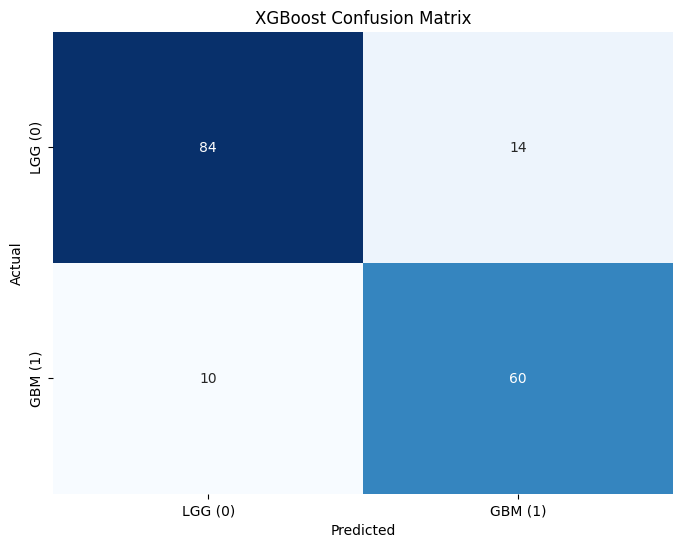

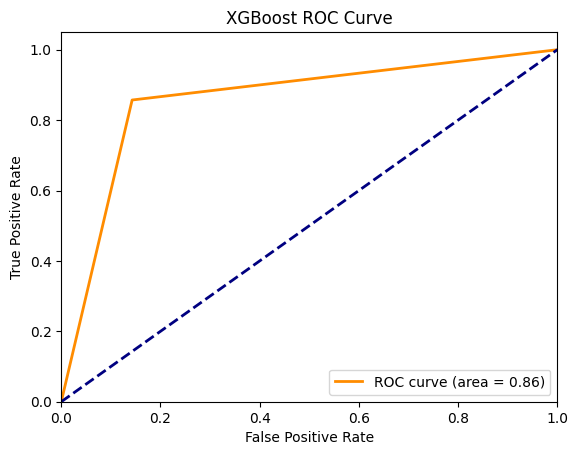

In [ ]:
# Establish the model
xgb = XGBClassifier(
  n_estimators = 200,
  max_depth = 3,
  learning_rate = 0.05,
  random_state = 42,
  subsample = 0.8,
  colsample_bytree = 0.8,
  reg_alpha = 0.1,
  reg_lambda = 1,
  gamma = 0
)

# Train the model
xgb.fit(X_train_scaled, y_train)

# Predict glioma class labels
y_pred_xgbtrain = xgb.predict(X_train_scaled)
y_pred_xgbtest = xgb.predict(X_test_scaled)

# Evaluate the model

print("XGBoost Train:")
print(classification_report(y_train, y_pred_xgbtrain))

print("XGBoost Test:")
print(classification_report(y_test, y_pred_xgbtest))

xgb_cm = confusion_matrix(y_test, y_pred_xgbtest)
plt.figure(figsize=(8, 6))
sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d', cmap='Blues', cbar=False,
    xticklabels = ['LGG (0)', 'GBM (1)'],
    yticklabels = ['LGG (0)', 'GBM (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgbtest)
xgb_roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % xgb_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Features ranked by importance
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
}).sort_values(by = "Importance", ascending = False).reset_index(drop=True)

print("\nRanking of Important Features:")
print(importances)


Ranking of Important Features:
             Feature  Importance
0               IDH1    0.475183
1                CIC    0.093827
2               IDH2    0.080186
3               PTEN    0.038725
4                NF1    0.033406
5                RB1    0.033001
6   Age_at_diagnosis    0.031624
7               EGFR    0.026041
8               ATRX    0.023442
9               TP53    0.022495
10            GRIN2A    0.021808
11             MUC16    0.021699
12            NOTCH1    0.021581
13            PIK3R1    0.017848
14            PDGFRA    0.013121
15              FAT4    0.012941
16           SMARCA4    0.012300
17            Gender    0.011185
18            PIK3CA    0.009587
19             FUBP1    0.000000
20             CSMD3    0.000000
21              BCOR    0.000000


#LightGBM

Light GBM Train:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       389
           1       0.88      0.92      0.90       282

    accuracy                           0.92       671
   macro avg       0.91      0.92      0.91       671
weighted avg       0.92      0.92      0.92       671

Light GBM Test:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        98
           1       0.81      0.84      0.83        70

    accuracy                           0.85       168
   macro avg       0.85      0.85      0.85       168
weighted avg       0.85      0.85      0.85       168



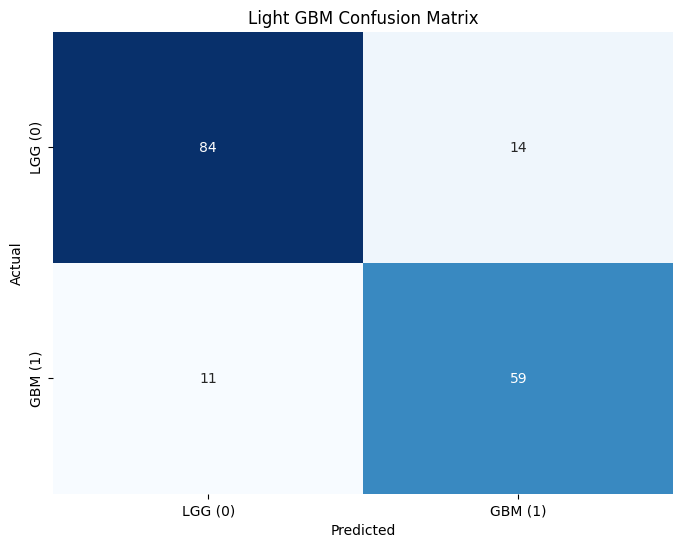

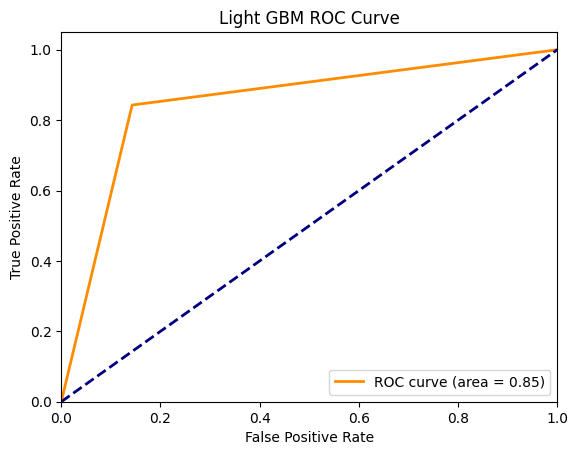

In [ ]:
# Establish the model
lgbm = XGBClassifier(
  n_estimators = 200,
  learning_rate = 0.05,
  max_depth = 10,
  subsample = 1.0,
  colsample_bytree = 0.6,
  reg_alpha = 1,
  reg_lambda = 0.1,
  gamma = 0.1
)

# Train the model
lgbm.fit(X_train_scaled, y_train)

# Predict glioma class labels
y_pred_lgbmtrain = lgbm.predict(X_train_scaled)
y_pred_lgbmtest = lgbm.predict(X_test_scaled)

# Evaluate the model

print("Light GBM Train:")
print(classification_report(y_train, y_pred_lgbmtrain))

print("Light GBM Test:")
print(classification_report(y_test, y_pred_lgbmtest))

lgbm_cm = confusion_matrix(y_test, y_pred_lgbmtest)
plt.figure(figsize=(8, 6))
sns.heatmap(
    lgbm_cm,
    annot=True,
    fmt='d', cmap='Blues', cbar=False,
    xticklabels = ['LGG (0)', 'GBM (1)'],
    yticklabels = ['LGG (0)', 'GBM (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Light GBM Confusion Matrix')
plt.show()

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_lgbmtest)
lgbm_roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % lgbm_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Light GBM ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Features ranked by importance
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm.feature_importances_
}).sort_values(by = "Importance", ascending = False).reset_index(drop=True)

print("\nRanking of Important Features:")
print(importances)


Ranking of Important Features:
             Feature  Importance
0               IDH1    0.461216
1                CIC    0.144992
2               PTEN    0.063256
3              FUBP1    0.058513
4               IDH2    0.056346
5               ATRX    0.032947
6                RB1    0.019931
7   Age_at_diagnosis    0.018432
8               TP53    0.016871
9             PIK3R1    0.016195
10               NF1    0.015025
11            NOTCH1    0.014936
12           SMARCA4    0.012089
13              EGFR    0.011800
14             MUC16    0.008756
15            GRIN2A    0.008110
16              FAT4    0.007929
17             CSMD3    0.007219
18              BCOR    0.007199
19            Gender    0.006306
20            PIK3CA    0.006011
21            PDGFRA    0.005922


#SVM RBF Kernel

SVM (RBF Kernel) Train:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       389
           1       0.90      0.96      0.93       282

    accuracy                           0.94       671
   macro avg       0.93      0.94      0.94       671
weighted avg       0.94      0.94      0.94       671

SVM (RBF Kernel) Test:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84        98
           1       0.77      0.79      0.78        70

    accuracy                           0.82       168
   macro avg       0.81      0.81      0.81       168
weighted avg       0.82      0.82      0.82       168



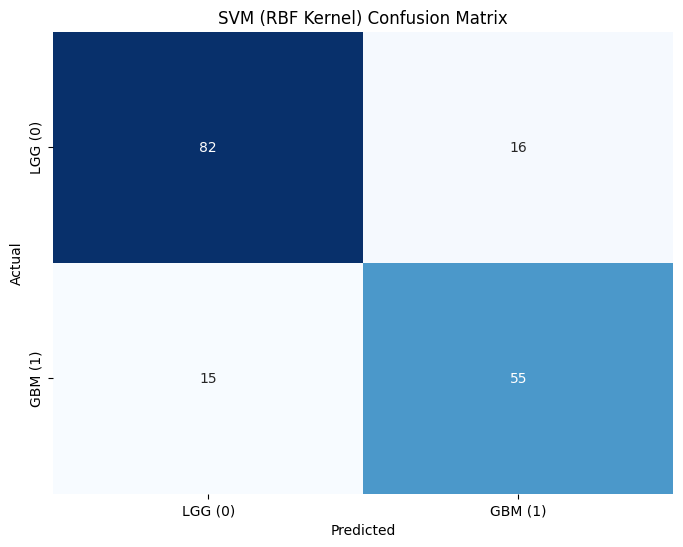

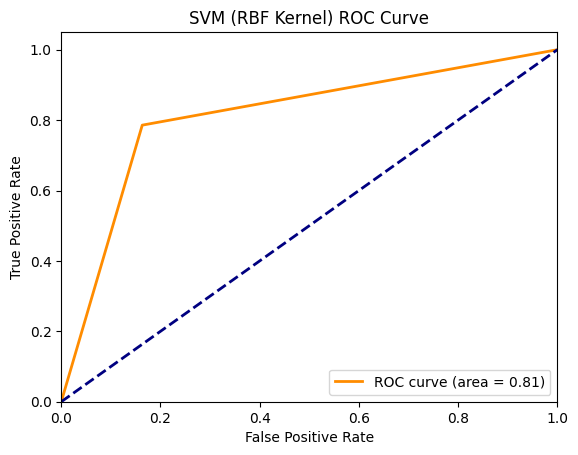

In [ ]:
# Establish the model
svm = SVC(
  kernel = 'rbf',
  C = 100,
  gamma = 'scale',
  class_weight = 'balanced'
)

# Train the model
svm.fit(X_train_scaled, y_train)

# Predict glioma class labels
y_pred_svmtrain = svm.predict(X_train_scaled)
y_pred_svmtest = svm.predict(X_test_scaled)

# Evaluate the model

print("SVM (RBF Kernel) Train:")
print(classification_report(y_train, y_pred_svmtrain))

print("SVM (RBF Kernel) Test:")
print(classification_report(y_test, y_pred_svmtest))

svm_cm = confusion_matrix(y_test, y_pred_svmtest)
plt.figure(figsize=(8, 6))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d', cmap='Blues', cbar=False,
    xticklabels = ['LGG (0)', 'GBM (1)'],
    yticklabels = ['LGG (0)', 'GBM (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM (RBF Kernel) Confusion Matrix')
plt.show()

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svmtest)
svm_roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % svm_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM (RBF Kernel) ROC Curve')
plt.legend(loc="lower right")
plt.show()

#K-Nearest Neighbors

KNN Train:
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       389
           1       0.83      0.90      0.86       282

    accuracy                           0.88       671
   macro avg       0.88      0.88      0.88       671
weighted avg       0.88      0.88      0.88       671

KNN Test:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        98
           1       0.82      0.86      0.84        70

    accuracy                           0.86       168
   macro avg       0.86      0.86      0.86       168
weighted avg       0.86      0.86      0.86       168



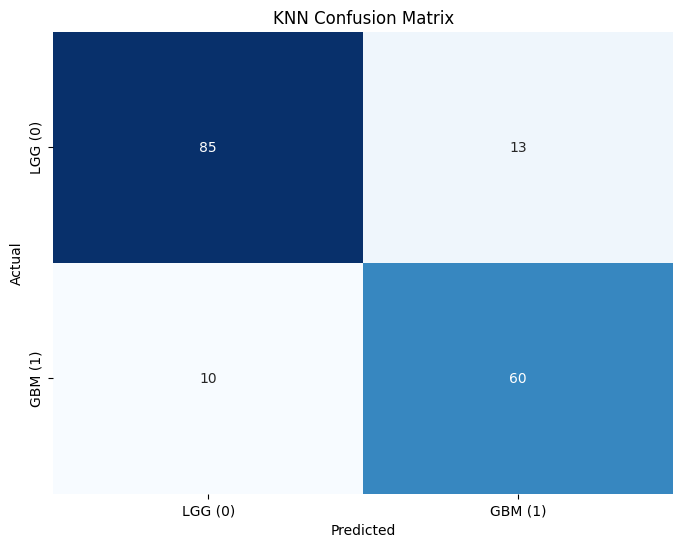

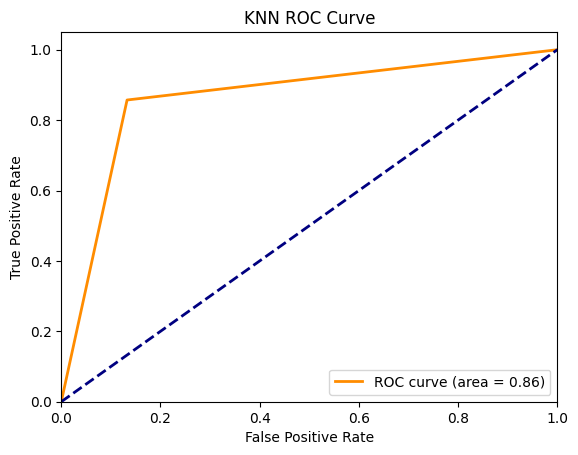

In [ ]:
# Establish the model
knn = KNeighborsClassifier(
    n_neighbors = 9,
    weights = 'uniform',
    metric = 'manhattan'
)

# Train the model
knn.fit(X_train_scaled, y_train)

# Predict glioma class labels
y_pred_knntrain = knn.predict(X_train_scaled)
y_pred_knntest = knn.predict(X_test_scaled)

# Evaluate the model

print("KNN Train:")
print(classification_report(y_train, y_pred_knntrain))

print("KNN Test:")
print(classification_report(y_test, y_pred_knntest))

knn_cm = confusion_matrix(y_test, y_pred_knntest)
plt.figure(figsize=(8, 6))
sns.heatmap(
    knn_cm,
    annot=True,
    fmt='d', cmap='Blues', cbar=False,
    xticklabels = ['LGG (0)', 'GBM (1)'],
    yticklabels = ['LGG (0)', 'GBM (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_knntest)
knn_roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % knn_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.legend(loc="lower right")
plt.show()

#Decision Tree

Decision Tree Train:
              precision    recall  f1-score   support

           0       0.95      0.86      0.91       389
           1       0.83      0.94      0.89       282

    accuracy                           0.90       671
   macro avg       0.89      0.90      0.90       671
weighted avg       0.90      0.90      0.90       671

Decision Tree Test:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86        98
           1       0.79      0.86      0.82        70

    accuracy                           0.85       168
   macro avg       0.84      0.85      0.84       168
weighted avg       0.85      0.85      0.85       168



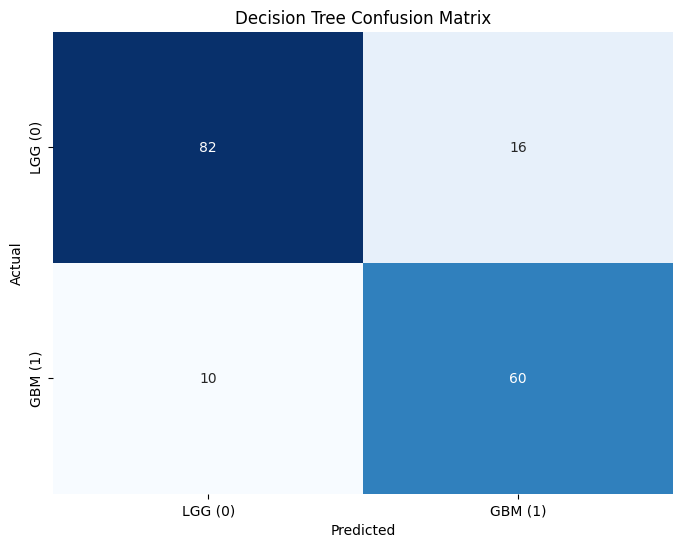

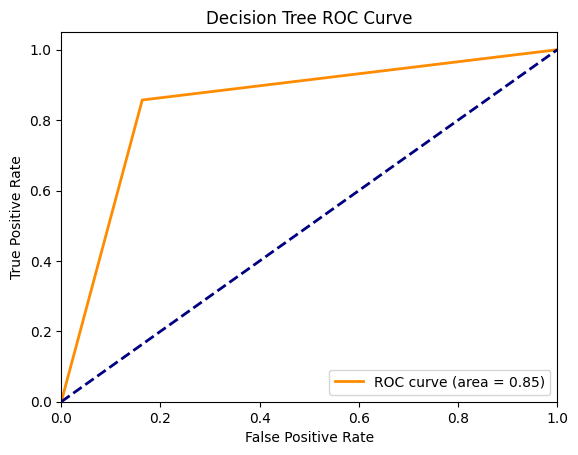

In [ ]:
# Establish the model
dt = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 10,
    min_samples_split = 10,
    min_samples_leaf = 2,
    class_weight = 'balanced'
)

# Train the model
dt.fit(X_train_scaled, y_train)

# Predict glioma class labels
y_pred_dttrain = dt.predict(X_train_scaled)
y_pred_dttest = dt.predict(X_test_scaled)

# Evaluate the model

print("Decision Tree Train:")
print(classification_report(y_train, y_pred_dttrain))

print("Decision Tree Test:")
print(classification_report(y_test, y_pred_dttest))

dt_cm = confusion_matrix(y_test, y_pred_dttest)
plt.figure(figsize=(8, 6))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d', cmap='Blues', cbar=False,
    xticklabels = ['LGG (0)', 'GBM (1)'],
    yticklabels = ['LGG (0)', 'GBM (1)']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

# ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_dttest)
dt_roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % dt_roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Features ranked by importance
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt.feature_importances_
}).sort_values(by = "Importance", ascending = False).reset_index(drop=True)

print("\nRanking of Important Features:")
print(importances)


Ranking of Important Features:
             Feature  Importance
0               IDH1    0.720421
1   Age_at_diagnosis    0.095285
2               IDH2    0.075881
3             GRIN2A    0.021445
4               EGFR    0.016050
5                NF1    0.015529
6               TP53    0.013155
7               PTEN    0.012198
8               ATRX    0.008261
9              MUC16    0.007523
10              FAT4    0.003240
11            PDGFRA    0.002725
12            Gender    0.001819
13              BCOR    0.001784
14            PIK3CA    0.001771
15               RB1    0.001699
16            PIK3R1    0.001213
17               CIC    0.000000
18             FUBP1    0.000000
19           SMARCA4    0.000000
20            NOTCH1    0.000000
21             CSMD3    0.000000


#Comparison of All Model Metrics

=== Model Comparison Summary ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.88,0.82,0.90,0.86,0.88
Random Forest,0.86,0.79,0.91,0.85,0.87
XGBoost,0.86,0.81,0.86,0.83,0.86
LightGBM,0.85,0.81,0.84,0.83,0.85
SVM (RBF),0.82,0.77,0.79,0.78,0.81
Decision Tree,0.85,0.79,0.86,0.82,0.85


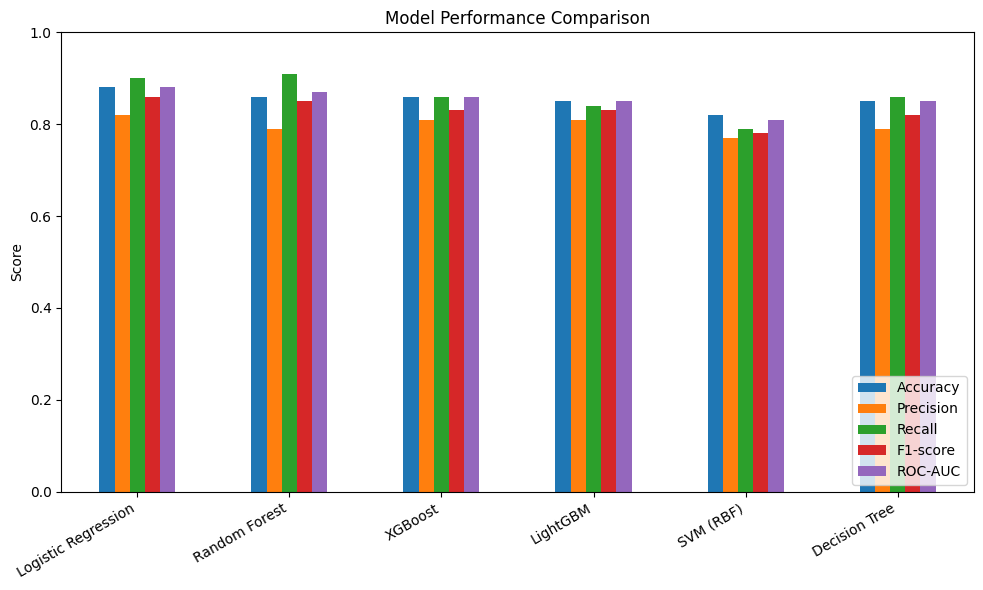

In [ ]:
# === 1. Imports ===
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === 2. Build a results dictionary ===
results = {
    "Logistic Regression": {
        "Accuracy":  accuracy_score(y_test, y_pred_logregtest),
        "Precision": precision_score(y_test, y_pred_logregtest),
        "Recall":    recall_score(y_test, y_pred_logregtest),
        "F1-score":  f1_score(y_test, y_pred_logregtest),
        "ROC-AUC":   lr_roc_auc
    },
    "Random Forest": {
        "Accuracy":  accuracy_score(y_test, y_pred_rftest),
        "Precision": precision_score(y_test, y_pred_rftest),
        "Recall":    recall_score(y_test, y_pred_rftest),
        "F1-score":  f1_score(y_test, y_pred_rftest),
        "ROC-AUC":   rf_roc_auc
    },
    "XGBoost": {
        "Accuracy":  accuracy_score(y_test, y_pred_xgbtest),
        "Precision": precision_score(y_test, y_pred_xgbtest),
        "Recall":    recall_score(y_test, y_pred_xgbtest),
        "F1-score":  f1_score(y_test, y_pred_xgbtest),
        "ROC-AUC":   xgb_roc_auc
    },
    "LightGBM": {
        "Accuracy":  accuracy_score(y_test, y_pred_lgbmtest),
        "Precision": precision_score(y_test, y_pred_lgbmtest),
        "Recall":    recall_score(y_test, y_pred_lgbmtest),
        "F1-score":  f1_score(y_test, y_pred_lgbmtest),
        "ROC-AUC":   lgbm_roc_auc
    },
    "SVM (RBF)": {
        "Accuracy":  accuracy_score(y_test, y_pred_svmtest),
        "Precision": precision_score(y_test, y_pred_svmtest),
        "Recall":    recall_score(y_test, y_pred_svmtest),
        "F1-score":  f1_score(y_test, y_pred_svmtest),
        "ROC-AUC":   svm_roc_auc
    },
    "Decision Tree": {
        "Accuracy":  accuracy_score(y_test, y_pred_dttest),
        "Precision": precision_score(y_test, y_pred_dttest),
        "Recall":    recall_score(y_test, y_pred_dttest),
        "F1-score":  f1_score(y_test, y_pred_dttest),
        "ROC-AUC":   dt_roc_auc
    }
}

# === 3. Convert to DataFrame and round ===
results_df = pd.DataFrame(results).T.round(2)
print("=== Model Comparison Summary ===")
display(results_df)

# === 4. Optional: add a column for the best metric per row ===
results_df["Best Metric"] = results_df.idxmax(axis=1)

# === 5. Bar chart visualization ===
results_df.plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
